# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df = pd.read_csv("/kaggle/input/datasets/jumpingdino/german-credit-dataset/german_credit_data.csv")
df

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,< 100 DM,4 to < 7 years,3,female : divorced/separated/married,none,...,none,31,none,own,1,unskilled - resident,1,none,yes,good
996,< 0 DM,30,existing credits paid back duly till now,car (used),3857,< 100 DM,1 to < 4 years,4,male : divorced/separated,none,...,car,40,none,own,1,management/ self-employed/highly qualified emp...,1,"yes, registered under the customers name",yes,good
997,no checking account,12,existing credits paid back duly till now,radio/television,804,< 100 DM,>= 7 years,4,male : single,none,...,real estate,38,none,own,1,skilled employee/ official,1,none,yes,good
998,< 0 DM,45,existing credits paid back duly till now,radio/television,1845,< 100 DM,1 to < 4 years,4,male : single,none,...,savings agreement/life insurance,23,none,for free,1,skilled employee/ official,1,"yes, registered under the customers name",yes,bad


# 2. Data Cleaning

In [3]:
df.columns

Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [4]:
print(df.head())
print(df.info())


        status_account  month_duration  \
0               < 0 DM               6   
1        0 to < 200 DM              48   
2  no checking account              12   
3               < 0 DM              42   
4               < 0 DM              24   

                                      credit_history              purpose  \
0  critical account/ other credits existing (not ...     radio/television   
1           existing credits paid back duly till now     radio/television   
2  critical account/ other credits existing (not ...            education   
3           existing credits paid back duly till now  furniture/equipment   
4                    delay in paying off in the past            car (new)   

   credit_amount               status_savings years_employment  \
0           1169  unknown/ no savings account       >= 7 years   
1           5951                     < 100 DM   1 to < 4 years   
2           2096                     < 100 DM   4 to < 7 years   
3           7882    

In [5]:
print(df['target'].unique())

['good' 'bad']


In [6]:
# ==============================
# 1. Standardize Column Names
# ==============================
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)

# ==============================
# 2. Remove Duplicate Rows
# ==============================
df.drop_duplicates(inplace=True)

# ==============================
# 3. Handle Missing Values
# ==============================
# Separate numeric and categorical columns
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

# Impute numeric columns with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Impute categorical columns with mode
df[cat_cols] = df[cat_cols].apply(lambda x: x.fillna(x.mode()[0]))

# ==============================
# 4. Fix Data Formatting Issues
# ==============================
# Clean categorical text data
df[cat_cols] = df[cat_cols].apply(lambda x: x.str.strip().str.lower())

# Convert date-like columns (example)
for col in df.columns:
    if 'date' in col:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Convert numeric-looking strings
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors='ignore')

# ==============================
# 5. Drop Unnecessary Columns
# ==============================
# columns_to_drop = ['transactionid', 'accountid', 'deviceid', 'ip_address' ]  # modify as needed
# df.drop(columns=columns_to_drop, inplace=True, errors='ignore')

# ==============================
# 6. Rename Columns
# ==============================
# df.rename(columns={
#     'old_name': 'new_name',
#     'total_amt': 'total_amount'
# }, inplace=True)

# ==============================
# 7. Remove Outliers (IQR Method)
# ==============================
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

/tmp/ipykernel_57/430446325.py:42: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_numeric(df[col], errors='ignore')


In [7]:
df

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
6,no checking account,24,existing credits paid back duly till now,furniture/equipment,2835,500 to < 1000 dm,>= 7 years,3,male : single,none,...,car,53,none,own,1,skilled employee/ official,1,none,yes,good
7,0 to < 200 dm,36,existing credits paid back duly till now,car (used),6948,< 100 dm,1 to < 4 years,2,male : single,none,...,real estate,35,none,rent,1,management/ self-employed/highly qualified emp...,1,"yes, registered under the customers name",yes,good
8,no checking account,12,existing credits paid back duly till now,radio/television,3059,>= 1000 dm,4 to < 7 years,2,male : divorced/separated,none,...,none,61,none,own,1,unskilled - resident,1,none,yes,good
9,0 to < 200 dm,30,critical account/ other credits existing (not ...,car (new),5234,< 100 dm,unemployed,4,male : married/widowed,none,...,real estate,28,none,own,2,management/ self-employed/highly qualified emp...,1,none,yes,bad
10,0 to < 200 dm,12,existing credits paid back duly till now,car (new),1295,< 100 dm,< 1 year,3,female : divorced/separated/married,none,...,real estate,25,none,rent,1,skilled employee/ official,1,none,yes,bad
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,< 0 dm,36,existing credits paid back duly till now,furniture/equipment,3959,< 100 dm,unemployed,4,male : single,none,...,car,30,none,own,1,management/ self-employed/highly qualified emp...,1,"yes, registered under the customers name",yes,good
994,no checking account,12,existing credits paid back duly till now,car (new),2390,unknown/ no savings account,>= 7 years,4,male : single,none,...,real estate,50,none,own,1,skilled employee/ official,1,"yes, registered under the customers name",yes,good
995,no checking account,12,existing credits paid back duly till now,furniture/equipment,1736,< 100 dm,4 to < 7 years,3,female : divorced/separated/married,none,...,none,31,none,own,1,unskilled - resident,1,none,yes,good
996,< 0 dm,30,existing credits paid back duly till now,car (used),3857,< 100 dm,1 to < 4 years,4,male : divorced/separated,none,...,car,40,none,own,1,management/ self-employed/highly qualified emp...,1,"yes, registered under the customers name",yes,good


# 3. Visualization

/tmp/ipykernel_57/3599861588.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette=palette)


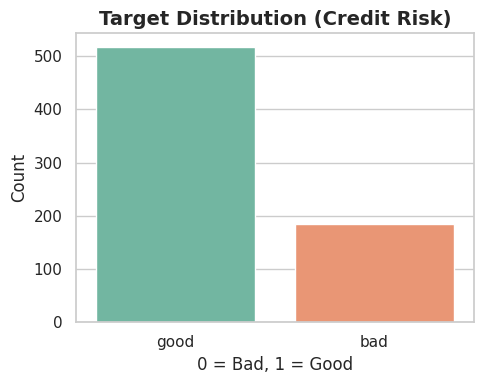

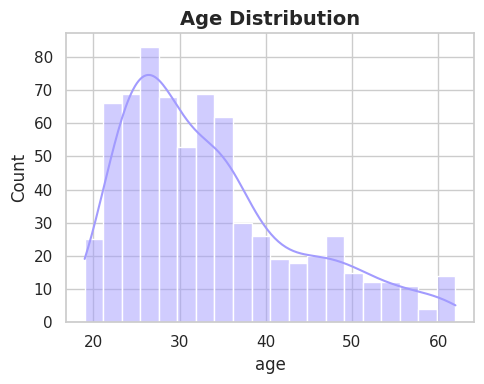

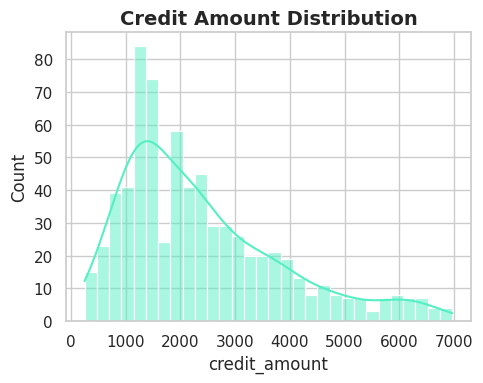

/tmp/ipykernel_57/3599861588.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='month_duration', data=df, palette=palette)


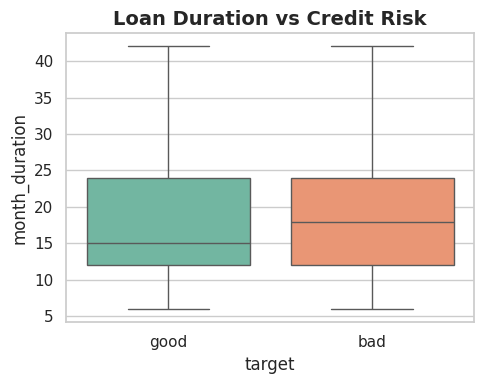

/tmp/ipykernel_57/3599861588.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='credit_amount', data=df, palette=palette)


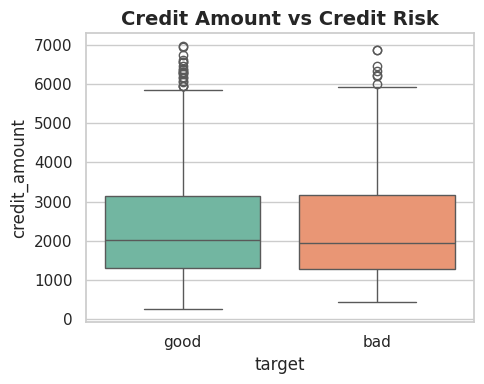

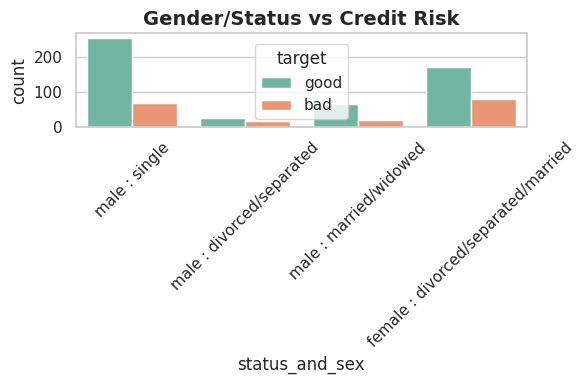

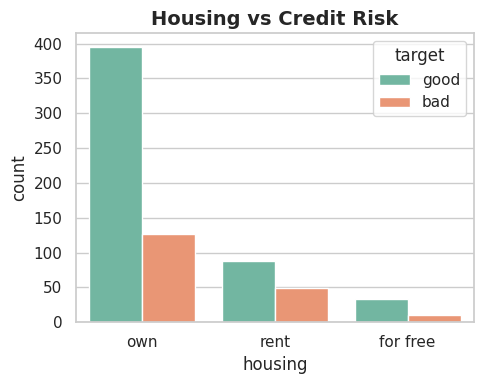

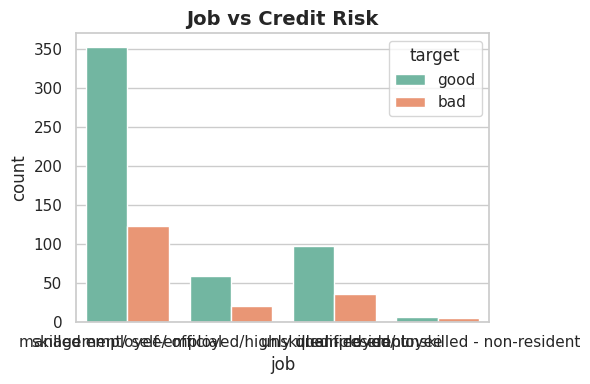

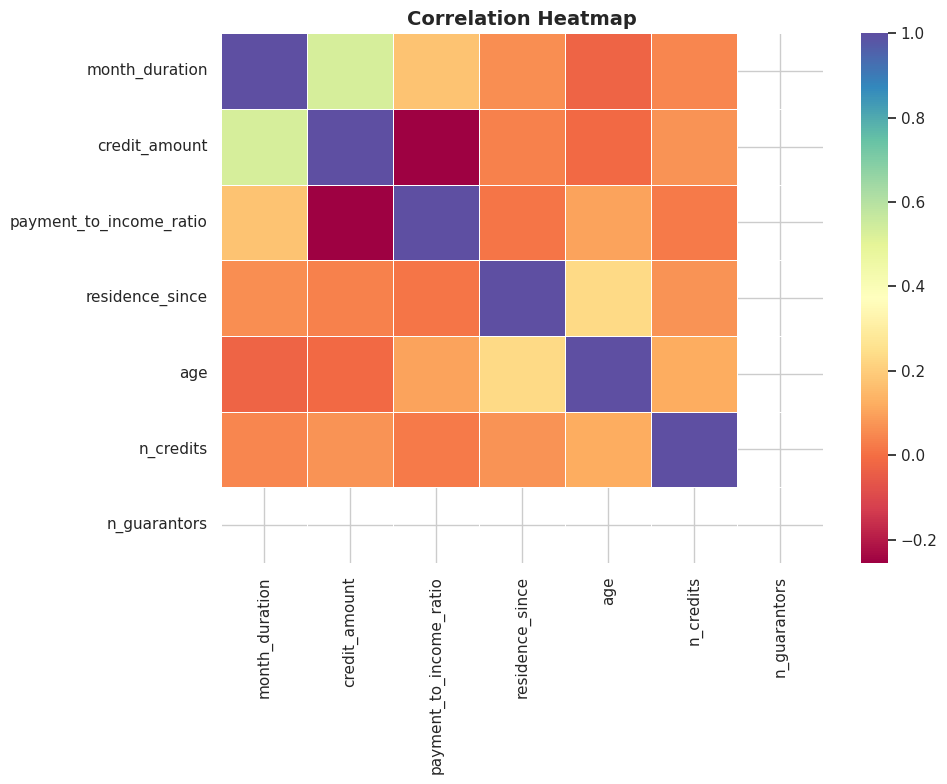

In [8]:
# ================================
# COMPLETE VISUALIZATION (ONE CELL)
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------
# GLOBAL PREMIUM STYLE ⭐
# -------------------------------
sns.set_theme(style="whitegrid")
palette = "Set2"

plt.rcParams.update({
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold"
})

# -------------------------------
# 1. Target Distribution
# -------------------------------
plt.figure(figsize=(5,4))
sns.countplot(x='target', data=df, palette=palette)
plt.title("Target Distribution (Credit Risk)")
plt.xlabel("0 = Bad, 1 = Good")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# -------------------------------
# 2. Age Distribution
# -------------------------------
plt.figure(figsize=(5,4))
sns.histplot(df['age'], bins=20, kde=True, color="#A29BFE")
plt.title("Age Distribution")
plt.tight_layout()
plt.show()

# -------------------------------
# 3. Credit Amount Distribution
# -------------------------------
plt.figure(figsize=(5,4))
sns.histplot(df['credit_amount'], bins=30, kde=True, color="#55EFC4")
plt.title("Credit Amount Distribution")
plt.tight_layout()
plt.show()

# -------------------------------
# 4. Duration vs Target
# -------------------------------
plt.figure(figsize=(5,4))
sns.boxplot(x='target', y='month_duration', data=df, palette=palette)
plt.title("Loan Duration vs Credit Risk")
plt.tight_layout()
plt.show()

# -------------------------------
# 5. Credit Amount vs Target
# -------------------------------
plt.figure(figsize=(5,4))
sns.boxplot(x='target', y='credit_amount', data=df, palette=palette)
plt.title("Credit Amount vs Credit Risk")
plt.tight_layout()
plt.show()

# -------------------------------
# 6. Sex & Status vs Target
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='status_and_sex', hue='target', data=df, palette=palette)
plt.title("Gender/Status vs Credit Risk")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# -------------------------------
# 7. Housing vs Target
# -------------------------------
plt.figure(figsize=(5,4))
sns.countplot(x='housing', hue='target', data=df, palette=palette)
plt.title("Housing vs Credit Risk")
plt.tight_layout()
plt.show()

# -------------------------------
# 8. Job vs Target
# -------------------------------
plt.figure(figsize=(6,4))
sns.countplot(x='job', hue='target', data=df, palette=palette)
plt.title("Job vs Credit Risk")
plt.tight_layout()
plt.show()

# -------------------------------
# 9. Correlation Heatmap
# -------------------------------
plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="Spectral",   # colorful gradient 🔥
    linewidths=0.5,
    linecolor='white'
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# 4. Preprocessing

In [9]:
# ==============================
# 1. Separate Features & Target
# ==============================
TARGET_COL = 'target'
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

In [10]:
# 2. One-Hot Encode ALL Categorical FEATURES
# ==============================
cat_cols = X.select_dtypes(include='object').columns

X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)

In [11]:
X

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors,status_account_< 0 dm,status_account_>= 200 dm,status_account_no checking account,...,collateral_savings agreement/life insurance,other_installment_plans_none,other_installment_plans_stores,housing_own,housing_rent,job_skilled employee/ official,job_unemployed/ unskilled - non-resident,job_unskilled - resident,"telephone_yes, registered under the customers name",is_foreign_worker_yes
6,24,2835,3,4,53,1,1,False,False,True,...,False,True,False,True,False,True,False,False,False,True
7,36,6948,2,2,35,1,1,False,False,False,...,False,True,False,False,True,False,False,False,True,True
8,12,3059,2,4,61,1,1,False,False,True,...,False,True,False,True,False,False,False,True,False,True
9,30,5234,4,2,28,2,1,False,False,False,...,False,True,False,True,False,False,False,False,False,True
10,12,1295,3,1,25,1,1,False,False,False,...,False,True,False,False,True,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,36,3959,4,3,30,1,1,True,False,False,...,False,True,False,True,False,False,False,False,True,True
994,12,2390,4,3,50,1,1,False,False,True,...,False,True,False,True,False,True,False,False,True,True
995,12,1736,3,4,31,1,1,False,False,True,...,False,True,False,True,False,False,False,True,False,True
996,30,3857,4,4,40,1,1,True,False,False,...,False,True,False,True,False,False,False,False,True,True


In [12]:
# 5. Feature Scaling (Standardization)
scaler = StandardScaler()
num_cols = X.select_dtypes(include=np.number).columns
X[num_cols] = scaler.fit_transform(X[num_cols])

In [13]:
# 5. Feature Scaling (Standardization)
print("Final Feature Shape:", X.shape)
print("Target Shape:", y.shape)

X.head(), y[:5]

Final Feature Shape: (702, 48)
Target Shape: (702,)


(    month_duration  credit_amount  payment_to_income_ratio  residence_since  \
 6         0.687806       0.301901                -0.069475         1.093345   
 7         2.111411       3.108075                -0.989695        -0.704145   
 8        -0.735800       0.454730                -0.989695         1.093345   
 9         1.399609       1.938665                 0.850745        -0.704145   
 10       -0.735800      -0.748793                -0.069475        -1.602890   
 
          age  n_credits  n_guarantors  status_account_< 0 dm  \
 6   1.949871  -0.693906           0.0                  False   
 7   0.146301  -0.693906           0.0                  False   
 8   2.751457  -0.693906           0.0                  False   
 9  -0.555087   1.216377           0.0                  False   
 10 -0.855682  -0.693906           0.0                  False   
 
     status_account_>= 200 dm  status_account_no checking account  ...  \
 6                      False                       

# 5. Train-Test Split 

In [14]:
# -------------------------------
# Train-Test Split
# -------------------------------
# 20% test size, random state for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # maintains class distribution
)

# -------------------------------
# Inspect first few rows
# -------------------------------
print("X_train head:\n", X_train.head())
print("\ny_train first 5 values:\n", y_train[:5])

X_train head:
      month_duration  credit_amount  payment_to_income_ratio  residence_since  \
117       -0.973068      -0.177734                -0.989695         0.194600   
483       -0.379899      -0.977354                -0.069475        -0.704145   
555       -0.735800      -0.724232                -0.989695        -1.602890   
45        -0.854434      -0.681931                 0.850745         1.093345   
135       -0.735800      -0.786318                 0.850745        -0.704145   

          age  n_credits  n_guarantors  status_account_< 0 dm  \
117 -0.655286   1.216377           0.0                   True   
483 -0.354691   1.216377           0.0                  False   
555 -1.156277  -0.693906           0.0                  False   
45   0.146301   1.216377           0.0                  False   
135  0.446896   1.216377           0.0                  False   

     status_account_>= 200 dm  status_account_no checking account  ...  \
117                     False          

#  6. LOGISTIC REGRESSION

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

In [16]:
y_pred_lr = lr.predict(X_test)    #prediction and accuracy 

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

=== Logistic Regression ===
Accuracy: 0.7872340425531915
              precision    recall  f1-score   support

         bad       0.62      0.49      0.55        37
        good       0.83      0.89      0.86       104

    accuracy                           0.79       141
   macro avg       0.73      0.69      0.70       141
weighted avg       0.78      0.79      0.78       141



#  7. Decision Tree

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [18]:
y_pred_dt = dt.predict(X_test)     #prediction and accuracy 

print("\n=== Decision Tree ===")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


=== Decision Tree ===
Accuracy: 0.7021276595744681
              precision    recall  f1-score   support

         bad       0.33      0.14      0.19        37
        good       0.75      0.90      0.82       104

    accuracy                           0.70       141
   macro avg       0.54      0.52      0.50       141
weighted avg       0.64      0.70      0.65       141



# 8. Confusion Matrix (BEST MODEL)

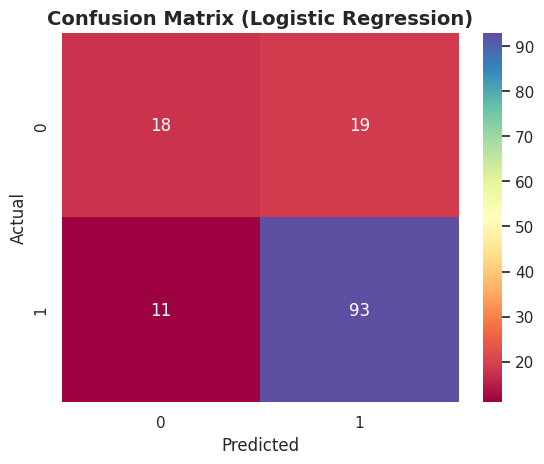

In [19]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Spectral')
plt.title("Confusion Matrix (Logistic Regression)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# 9. Feature Importance (DECISION TREE)

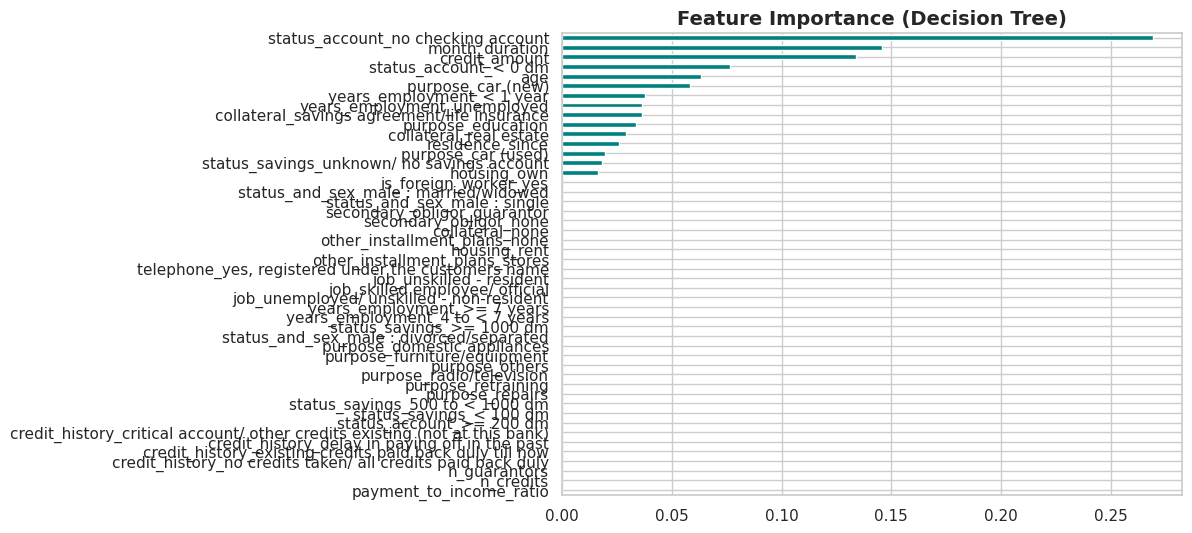

In [20]:
importance = dt.feature_importances_

feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind='barh', figsize=(8,6), color='teal')

plt.title("Feature Importance (Decision Tree)")
plt.show()

# 10. Model Comparison

/tmp/ipykernel_57/1264301730.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=accuracies, palette="Set2")


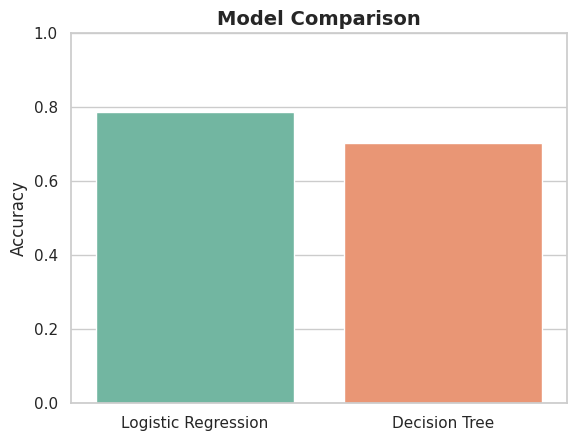

In [21]:
models = ['Logistic Regression', 'Decision Tree']
accuracies = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt)
]

plt.figure()
sns.barplot(x=models, y=accuracies, palette="Set2")
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()